In [1]:
import sys, os, pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import TwoSlopeNorm

# ── Project root ─────────────────────────────────────────────────────────────
PROJECT_ROOT = os.path.abspath('.')
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'toy_domain'))
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'MedGrid'))

import med_grid_env  # registers MedGrid-v0 and MedGrid-discrete-v0
import gymnasium as gym

# ── Run to analyse ───────────────────────────────────────────────────────────
RUN_NAME = 'medgrid_test_cont_run'   # change to match -info flag used during training
RUN_DIR  = os.path.join(PROJECT_ROOT, 'runs', RUN_NAME)

## 1. Ground truth regions

MedGrid is a **10×10** continuous gridworld with:
* **Red (Death):** quarter-circles of radius 3 at bottom-left $(0,0)$ and top-right $(10,10)$.
* **Yellow (Trap):** annular bands $3 < d \le 5$ around each death zone corner.
* **Blue (Recovery):** a rotated ellipse centred at $(5,5)$, semi-major $a=3$, semi-minor $b=1.5$, tilted $-45°$.
* **White (Neutral):** everything else.
* **Start:** bottom-right corner $(10, 0)$.

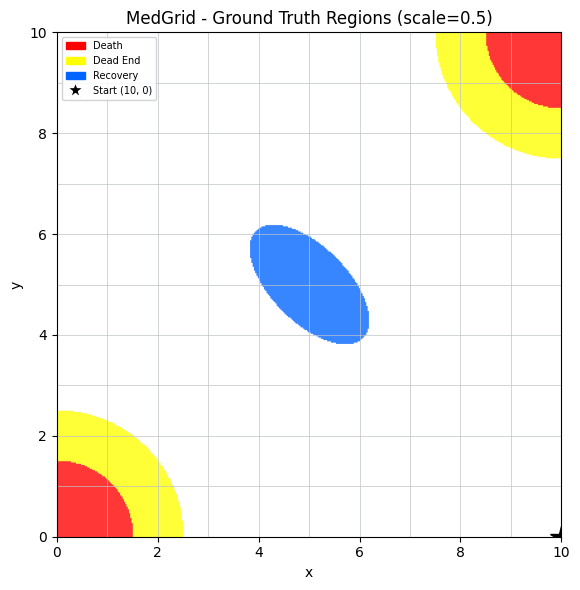

In [2]:
SCALE      = 0.5   # set < 1 to shrink danger/recovery zones proportionally
SIZE       = 10.0
DEATH_R    = 3.0 * SCALE
TRAP_R     = 5.0 * SCALE
ELLIPSE_A  = 3.0 * SCALE
ELLIPSE_B  = 1.5 * SCALE
RESOLUTION = 800

# Backward-compatible aliases used by later cells.
DEATH_COLOR_HEX    = '#ff0000'
DEAD_END_COLOR_HEX = '#ffff00'
RECOVERY_COLOR_HEX = '#0064ff'
NEUTRAL_COLOR_HEX  = '#ffffff'
START_COLOR_HEX    = '#000000'


def hex_to_rgba(hex_color, alpha=255):
    """Convert '#RRGGBB' color to an RGBA uint8 array."""
    value = hex_color.lstrip('#')
    if len(value) != 6:
        raise ValueError(f'Invalid hex color: {hex_color}')
    return np.array([
        int(value[0:2], 16),
        int(value[2:4], 16),
        int(value[4:6], 16),
        int(alpha),
    ], dtype=np.uint8)


def classify_point(x, y):
    """Return region label for a single (x, y) point."""
    d_bl = np.sqrt(x**2 + y**2)
    d_tr = np.sqrt((x - 10)**2 + (y - 10)**2)

    if d_bl <= DEATH_R or d_tr <= DEATH_R:
        return 'death'
    if d_bl <= TRAP_R or d_tr <= TRAP_R:
        return 'trap'
    dx, dy = x - 5.0, y - 5.0
    if ((dx - dy)**2 / (2 * ELLIPSE_A**2) + (dx + dy)**2 / (2 * ELLIPSE_B**2)) <= 1.0:
        return 'recovery'
    return 'neutral'


def build_region_image(resolution=RESOLUTION):
    """Rasterise the region map into an RGBA image for imshow."""
    colors = {
        'death':    hex_to_rgba(DEATH_COLOR_HEX, alpha=200),
        'trap':     hex_to_rgba(DEAD_END_COLOR_HEX, alpha=200),
        'recovery': hex_to_rgba(RECOVERY_COLOR_HEX, alpha=200),
        'neutral':  hex_to_rgba(NEUTRAL_COLOR_HEX, alpha=255),
    }
    xs = np.linspace(0, SIZE, resolution)
    ys = np.linspace(0, SIZE, resolution)
    img = np.zeros((resolution, resolution, 4), dtype=np.uint8)
    for j, y in enumerate(ys):
        for i, x in enumerate(xs):
            img[j, i] = colors[classify_point(x, y)]
    return img


def plot_ground_truth(ax=None, resolution=RESOLUTION):
    """Draw the MedGrid region layout. Returns (fig, ax)."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    img = build_region_image(resolution)
    ax.imshow(img, origin='lower', extent=[0, SIZE, 0, SIZE], aspect='equal')

    # 1-unit grid lines
    for i in range(11):
        ax.axhline(i, color='#bdc3c7', lw=0.5, zorder=2)
        ax.axvline(i, color='#bdc3c7', lw=0.5, zorder=2)

    # Start position
    ax.plot(10, 0, marker='*', color=START_COLOR_HEX, markersize=16,
            label='Start (10, 0)', zorder=5)

    # Legend patches
    legend_patches = [
        mpatches.Patch(color=DEATH_COLOR_HEX, label='Death'),
        mpatches.Patch(color=DEAD_END_COLOR_HEX, label='Dead End'),
        mpatches.Patch(color=RECOVERY_COLOR_HEX, label='Recovery'),
        plt.Line2D([0], [0], marker='*', color='w', markerfacecolor=START_COLOR_HEX,
                   markersize=12, label='Start (10, 0)'),
    ]
    ax.legend(handles=legend_patches, loc='upper left', fontsize=7, framealpha=0.85)

    ax.set_xlim(0, SIZE)
    ax.set_ylim(0, SIZE)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'MedGrid - Ground Truth Regions (scale={SCALE})')
    return fig, ax


fig, ax = plot_ground_truth(resolution=400)
plt.tight_layout()
plt.show()

## 4. Sanity check — environment API

In [3]:
env = gym.make('MedGrid-v0')
obs, _ = env.reset()
print(f'Start state: {obs}  (expected [10. 0.])')

# Step directly into recovery zone (centre 5,5)
obs, r, term, trunc, _ = env.step(np.array([5.0, 5.0]))
print(f'Step to (5,5): obs={obs}, reward={r}, terminated={term}  (expect +1, True)')

# Reset and step into death zone BL
obs, _ = env.reset()
obs, r, term, trunc, _ = env.step(np.array([1.0, 1.0]))
print(f'Step to (1,1): obs={obs}, reward={r}, terminated={term}  (expect -1, True)')

# Reset and step into Trap1, then verify forced transition
obs, _ = env.reset()
obs, r, term, trunc, _ = env.step(np.array([4.0, 0.5]))   # inside Trap1 band
print(f'Step to BL trap (4.0,0.5): obs={obs}, reward={r}, terminated={term}  (expect 0, False)')
obs2, r2, term2, trunc2, _ = env.step(np.array([8.0, 8.0]))  # action ignored
print(f'Forced from Trap1:          obs={obs2}, reward={r2}, terminated={term2}  (expect [1.5 1.5], -1, True)')

env.close()

Start state: [10.  0.]  (expected [10. 0.])
Step to (5,5): obs=[5. 5.], reward=1.0, terminated=True  (expect +1, True)
Step to (1,1): obs=[1. 1.], reward=-1.0, terminated=True  (expect -1, True)
Step to BL trap (4.0,0.5): obs=[4.  0.5], reward=0.0, terminated=False  (expect 0, False)
Forced from Trap1:          obs=[1.5 1.5], reward=-1.0, terminated=True  (expect [1.5 1.5], -1, True)


## 5. Discrete wrapper sanity check

In [4]:
env_d = gym.make('MedGrid-discrete-v0', n_bins=11)
obs, _ = env_d.reset()
print(f'Discrete action space size (n_bins=11): {env_d.action_space.n}  (expect 121)')
print(f'Observation space: {env_d.observation_space}')
env_d.close()

Discrete action space size (n_bins=11): 121  (expect 121)
Observation space: Box(0.0, 10.0, (2,), float32)


## 6. Load trained agents (after training)

Run training first:
```bash
cd toy_domain
../.venv/bin/python run.py -env MedGrid -action_mode discrete -n_bins 11 \
    -agent iqn -ded -frames 500000 -info medgrid_iqn
```

In [5]:
import io

RUN_NAME = 'medgrid_test_cont'   # change to match -info flag used during training
RUN_DIR  = os.path.join(PROJECT_ROOT, 'runs', RUN_NAME)


class CpuUnpickler(pickle.Unpickler):
    """Unpickler that maps CUDA-backed torch storages onto CPU."""
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(
                io.BytesIO(b), map_location=torch.device('cpu'), weights_only=False
            )
        return super().find_class(module, name)


def load_pickle_cpu(path):
    with open(path, 'rb') as f:
        return CpuUnpickler(f).load()


agent, qd, qr = None, None, None
try:
    agent = load_pickle_cpu(os.path.join(RUN_DIR, f'{RUN_NAME}_agent.pkl'))
    print('Loaded main agent')
    qd = load_pickle_cpu(os.path.join(RUN_DIR, f'{RUN_NAME}_Qd.pkl'))
    qr = load_pickle_cpu(os.path.join(RUN_DIR, f'{RUN_NAME}_Qr.pkl'))
    print('Loaded Qd and Qr networks')
except FileNotFoundError as e:
    print(f'Agents not found ({e}) - train first with the command above.')
except RuntimeError as e:
    print(f'Failed to load agents due to runtime error: {e}')

Loaded main agent
Loaded Qd and Qr networks


## 7. CVaR Q-value heatmaps over action space at state (5, 0)

For a fixed start-region state we sweep the 10×10 action space and compute the
**lower CVaR** of the IQN quantile distribution at each action.

Only runs if agents were loaded above.

CVaR with alpha=0.2)
Randomly sampling 3000 actions for state [10, 0]
Computing Qd scatter...
  range: [-1.088, -0.011]
Computing Qr scatter...
  range: [-0.034, 1.012]


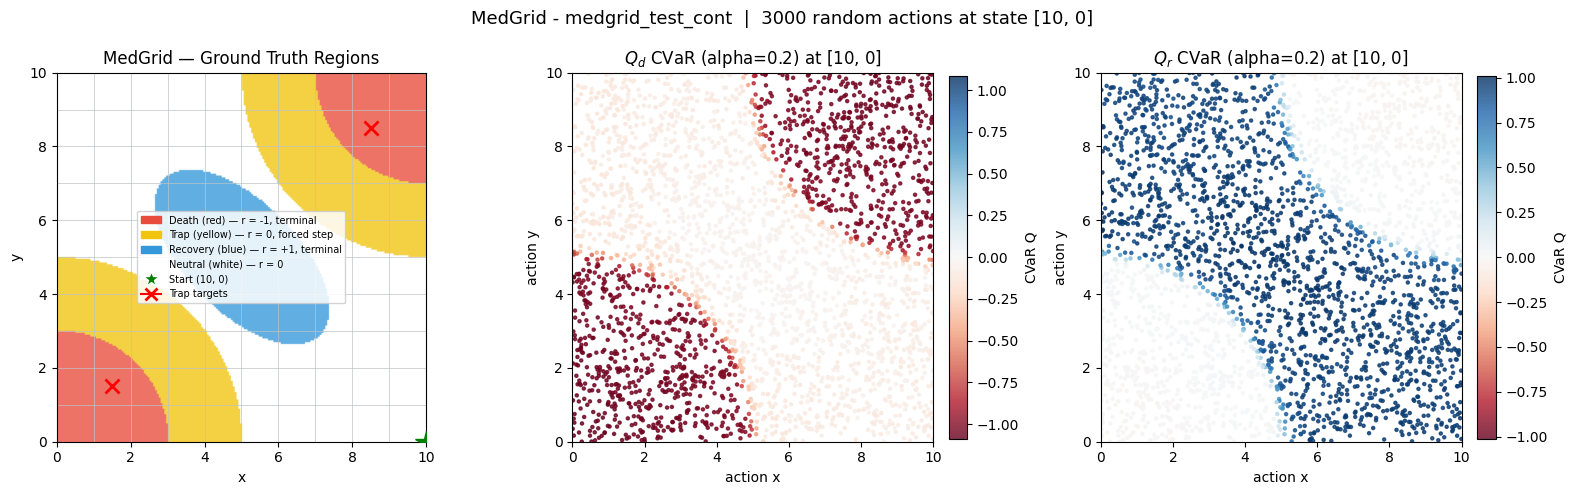

Saved to /home/jay/Uni/SafetyResearch/runs/medgrid_test_cont/medgrid_ded_action_scatter.png


In [ ]:
N_ACTIONS = 20000
N_TAU = 32
alpha   = 0.2
DEVICE = 'cpu'
FIXED_STATE = [10, 0]

N_KEEP = max(1, int(alpha * N_TAU))
print(f'CVaR with alpha={alpha})')
print(f'Randomly sampling {N_ACTIONS} actions for state {FIXED_STATE}')


def _prepare_iqn_for_device(ded_agent, device):
    network = ded_agent.qnetwork_local
    network.to(device)
    network.device = device
    if hasattr(network, 'pis'):
        network.pis = network.pis.to(device)
    return network


def compute_action_scatter(ded_agent, state=FIXED_STATE, n_actions=N_ACTIONS,
                            n_tau=N_TAU, eta=alpha, device=DEVICE, seed=42):
    rng = np.random.default_rng(seed)
    actions = rng.uniform(0.0, 10.0, size=(n_actions, 2)).astype(np.float32)

    s = np.array([state], dtype=np.float32)
    states = np.tile(s, (n_actions, 1))

    n_keep = max(1, int(eta * n_tau))
    network = _prepare_iqn_for_device(ded_agent, device)
    network.eval()

    s_t = torch.from_numpy(states).to(device)
    a_t = torch.from_numpy(actions).to(device)

    with torch.no_grad():
        quantiles, _ = network.forward(s_t, a_t, num_tau=n_tau)

    q = quantiles.squeeze(-1).cpu().numpy()
    q_sorted = np.sort(q, axis=1)
    cvar = q_sorted[:, :n_keep].mean(axis=1)
    return cvar, actions


def plot_action_scatter(cvar, actions, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    else:
        fig = ax.figure
    vmax = max(np.abs(cvar).max(), 1e-6)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    sc = ax.scatter(actions[:, 0], actions[:, 1], c=cvar,
                    cmap='RdBu', norm=norm, s=5, alpha=0.8)
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label='CVaR Q')
    ax.set_xlim(0, 10); ax.set_ylim(0, 10)
    ax.set_xlabel('action x'); ax.set_ylabel('action y')
    ax.set_title(title)
    return fig, ax


if qd is not None and qr is not None:
    print('Computing Qd scatter...')
    cvar_d, actions_d = compute_action_scatter(qd)
    print(f'  range: [{cvar_d.min():.3f}, {cvar_d.max():.3f}]')

    print('Computing Qr scatter...')
    cvar_r, actions_r = compute_action_scatter(qr)
    print(f'  range: [{cvar_r.min():.3f}, {cvar_r.max():.3f}]')

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    plot_ground_truth(ax=axes[0], resolution=200)
    plot_action_scatter(cvar_d, actions_d,
                        title=f'$Q_d$ CVaR (alpha={alpha}) at {FIXED_STATE}', ax=axes[1])
    plot_action_scatter(cvar_r, actions_r,
                        title=f'$Q_r$ CVaR (alpha={alpha}) at {FIXED_STATE}', ax=axes[2])
    fig.suptitle(f'MedGrid - {RUN_NAME}  |  {N_ACTIONS} random actions at state {FIXED_STATE}', fontsize=13)
    plt.tight_layout()
    out_path = os.path.join(RUN_DIR, 'medgrid_ded_action_scatter.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved to', out_path)
else:
    print('Skipped - no trained agents loaded.')


## 8. Confusion Matrix — Continuous Action Space

Evaluate the DistDeD dead-end predictions across a grid of states using **both** $Q_d$ and $Q_r$ networks.
For each state, random actions are sampled and the **median CVaR** over actions is computed per network.

**Dead-end criterion (DistDeD §4):** $\text{median}_a[\text{CVaR}(Z_D(s,\cdot))] \leq \delta_D$ **AND** $\text{median}_a[\text{CVaR}(Z_R(s,\cdot))] \leq \delta_R$

**Ground truth:** `classify_point` returning `'death'` or `'trap'`.

Evaluating DistDeD on 50×50 state grid (200 actions/state) …
  δD = -0.5,  δR = 0.5,  α = 0.2


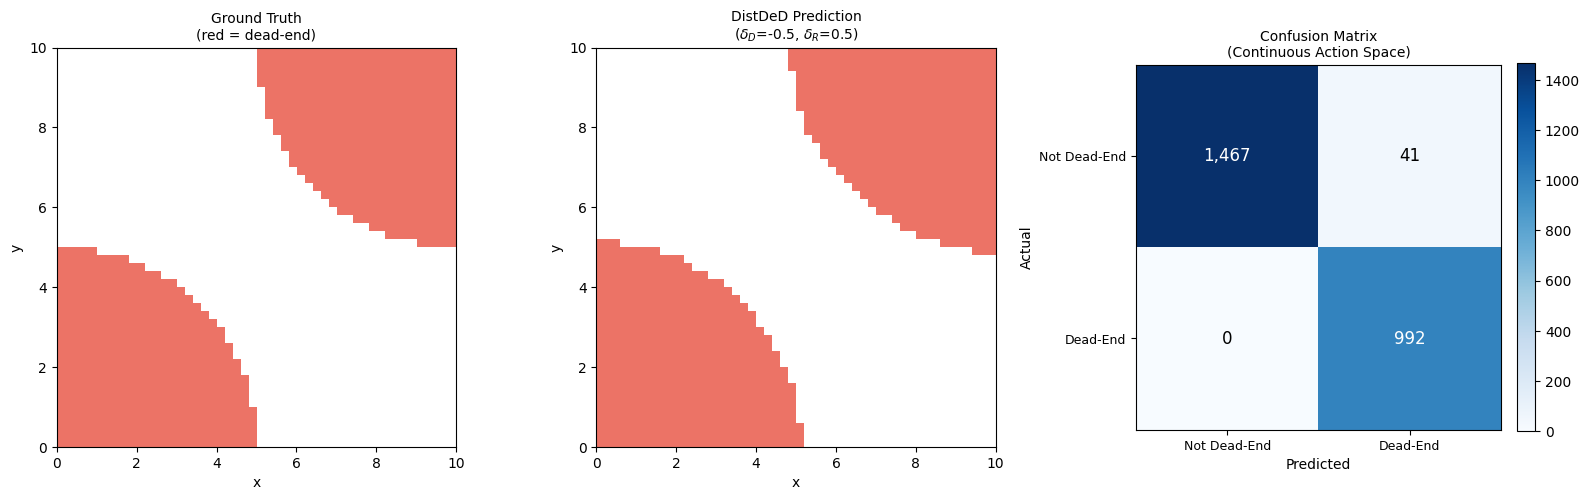


TP=992  TN=1467  FP=41  FN=0


In [7]:
GRID_RES       = 50     # state-space grid resolution (GRID_RES x GRID_RES points)
N_EVAL_ACTIONS = 200    # random actions sampled per state
DELTA_D        = -0.5   # dead-end threshold for D-network (median CVaR_D ≤ δD)
DELTA_R        =  0.5   # dead-end threshold for R-network (median CVaR_R ≤ δR)
CHUNK_SIZE     = 20000  # forward-pass batch size


def _cvar_from_network(network, states_exp, actions_exp, n_tau, n_keep, device):
    """Run chunked forward pass and return CVaR per (state, action) pair."""
    cvar_chunks = []
    for start in range(0, len(states_exp), CHUNK_SIZE):
        s_t = torch.from_numpy(states_exp[start:start + CHUNK_SIZE]).to(device)
        a_t = torch.from_numpy(actions_exp[start:start + CHUNK_SIZE]).to(device)
        with torch.no_grad():
            quantiles, _ = network.forward(s_t, a_t, num_tau=n_tau)
        q = quantiles.squeeze(-1).cpu().numpy()
        q_sorted = np.sort(q, axis=1)
        cvar_chunks.append(q_sorted[:, :n_keep].mean(axis=1))
    return np.concatenate(cvar_chunks)


def evaluate_state_grid(qd_agent, qr_agent, grid_res=GRID_RES, n_actions=N_EVAL_ACTIONS,
                         delta_d=DELTA_D, delta_r=DELTA_R, n_tau=N_TAU, eta=alpha,
                         device=DEVICE, seed=7):
    """Return (gt_grid, pred_grid, median_cvar_d_grid, median_cvar_r_grid).

    Dead-end criterion (DistDeD, §4):
        median_a[CVaR(ZD(s,·))] ≤ δD  AND  median_a[CVaR(ZR(s,·))] ≤ δR

    gt_grid          : bool (G, G) — True where ground truth is dead-end
    pred_grid        : bool (G, G) — True where both thresholds are breached
    median_cvar_d/r  : float (G, G) — per-state median CVaR values
    """
    xs = np.linspace(0, SIZE, grid_res)
    ys = np.linspace(0, SIZE, grid_res)
    xx, yy = np.meshgrid(xs, ys)
    all_states = np.stack([xx.ravel(), yy.ravel()], axis=1).astype(np.float32)  # (N, 2)
    N = len(all_states)

    # Ground truth: death or trap → dead-end
    gt_flat = np.array(
        [classify_point(s[0], s[1]) in ('death', 'trap') for s in all_states],
        dtype=bool,
    )

    # Same random actions reused for every state
    rng = np.random.default_rng(seed)
    actions = rng.uniform(0.0, SIZE, size=(n_actions, 2)).astype(np.float32)

    # Expand: each state paired with all n_actions actions
    states_exp  = np.repeat(all_states, n_actions, axis=0)   # (N*A, 2)
    actions_exp = np.tile(actions, (N, 1))                    # (N*A, 2)

    n_keep = max(1, int(eta * n_tau))

    # ── D-network ─────────────────────────────────────────────────────────────
    net_d = _prepare_iqn_for_device(qd_agent, device)
    net_d.eval()
    cvar_d_flat = _cvar_from_network(net_d, states_exp, actions_exp, n_tau, n_keep, device)
    # shape (N, A) → median over actions
    median_cvar_d = np.median(cvar_d_flat.reshape(N, n_actions), axis=1)   # (N,)

    # ── R-network ─────────────────────────────────────────────────────────────
    net_r = _prepare_iqn_for_device(qr_agent, device)
    net_r.eval()
    cvar_r_flat = _cvar_from_network(net_r, states_exp, actions_exp, n_tau, n_keep, device)
    median_cvar_r = np.median(cvar_r_flat.reshape(N, n_actions), axis=1)   # (N,)

    # DistDeD dead-end condition: BOTH thresholds must be breached
    pred_flat = (median_cvar_d <= delta_d) & (median_cvar_r <= delta_r)

    return (
        gt_flat.reshape(grid_res, grid_res),
        pred_flat.reshape(grid_res, grid_res),
        median_cvar_d.reshape(grid_res, grid_res),
        median_cvar_r.reshape(grid_res, grid_res),
    )


def plot_confusion_matrix(cm, ax=None):
    """Plot a 2×2 confusion matrix with annotations."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 3.5))
    else:
        fig = ax.figure

    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    labels = ['Not Dead-End', 'Dead-End']
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels, fontsize=9)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)
    ax.set_title('Confusion Matrix\n(Continuous Action Space)', fontsize=10)

    thresh = cm.max() / 2.0
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center', fontsize=12,
                    color='white' if cm[i, j] > thresh else 'black')
    return fig, ax


if qd is not None and qr is not None:
    print(f'Evaluating DistDeD on {GRID_RES}×{GRID_RES} state grid '
          f'({N_EVAL_ACTIONS} actions/state) …')
    print(f'  δD = {DELTA_D},  δR = {DELTA_R},  α = {alpha}')
    gt_grid, pred_grid, median_cvar_d_grid, median_cvar_r_grid = evaluate_state_grid(qd, qr)

    # Build confusion matrix  [ [TN, FP], [FN, TP] ]
    gt_flat   = gt_grid.ravel()
    pred_flat = pred_grid.ravel()
    TP = int(( gt_flat &  pred_flat).sum())
    TN = int((~gt_flat & ~pred_flat).sum())
    FP = int((~gt_flat &  pred_flat).sum())
    FN = int(( gt_flat & ~pred_flat).sum())
    cm = np.array([[TN, FP], [FN, TP]])

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Ground truth map
    gt_rgba = np.zeros((*gt_grid.shape, 4), dtype=np.uint8)
    gt_rgba[ gt_grid] = [231,  76,  60, 200]
    gt_rgba[~gt_grid] = [255, 255, 255, 220]
    axes[0].imshow(gt_rgba, origin='lower', extent=[0, SIZE, 0, SIZE])
    axes[0].set_title('Ground Truth\n(red = dead-end)', fontsize=10)
    axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

    # Predicted map
    pred_rgba = np.zeros((*pred_grid.shape, 4), dtype=np.uint8)
    pred_rgba[ pred_grid] = [231,  76,  60, 200]
    pred_rgba[~pred_grid] = [255, 255, 255, 220]
    axes[1].imshow(pred_rgba, origin='lower', extent=[0, SIZE, 0, SIZE])
    axes[1].set_title(
        f'DistDeD Prediction\n($\\delta_D$={DELTA_D}, $\\delta_R$={DELTA_R})', fontsize=10)
    axes[1].set_xlabel('x'); axes[1].set_ylabel('y')

    plot_confusion_matrix(cm, ax=axes[2])

    plt.tight_layout()
    plt.savefig(os.path.join(RUN_DIR, 'confusion_matrix_cont.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\nTP={TP}  TN={TN}  FP={FP}  FN={FN}')
else:
    print('Skipped — no trained agents loaded.')


## 9. Classification Metrics — Continuous Action Space

Metrics computed from the state-grid evaluation above:

| Metric | Definition |
|--------|-----------|
| **Precision** | TP / (TP + FP) — of predicted dead-ends, how many are real |
| **Recall** | TP / (TP + FN) — of real dead-ends, how many are detected |
| **F1** | Harmonic mean of precision and recall |
| **Boundary IoU** | IoU of the *boundary pixels* of predicted vs GT dead-end region |

  Classification Metrics  (δD=-0.5, δR=0.5)
  Precision      : 0.9603
  Recall         : 1.0000
  F1 Score       : 0.9798
  Boundary IoU   : 0.2703


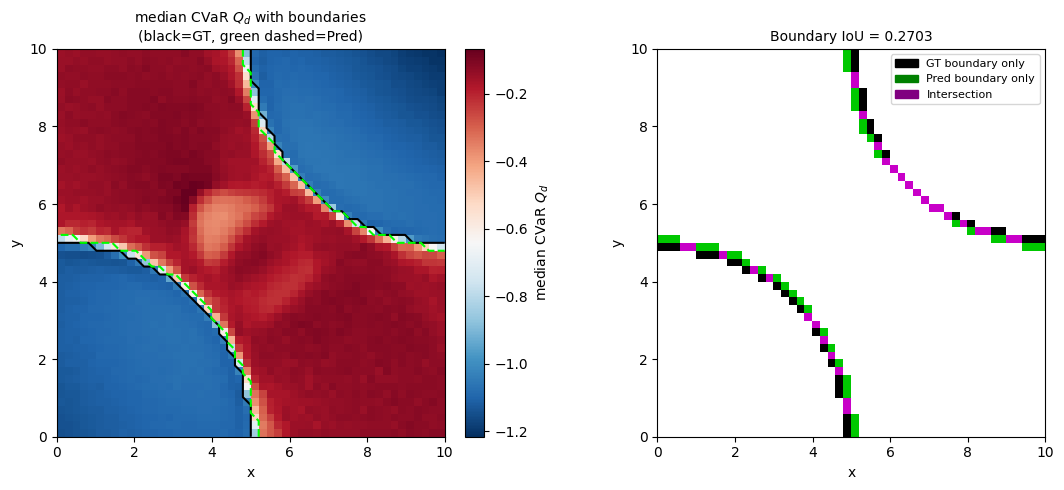

In [8]:
def boundary_mask(binary_grid):
    """Return a boolean mask of boundary pixels (True pixels adjacent to a False pixel)."""
    g = binary_grid.astype(np.int8)
    # A pixel is on the boundary if it differs from any of its 4-connected neighbours
    shifted = (
        np.pad(g, ((1, 0), (0, 0)), mode='edge')[:-1, :]  # up
        + np.pad(g, ((0, 1), (0, 0)), mode='edge')[1:, :]   # down
        + np.pad(g, ((0, 0), (1, 0)), mode='edge')[:, :-1]  # left
        + np.pad(g, ((0, 0), (0, 1)), mode='edge')[:, 1:]   # right
    )
    # A dead-end pixel is on the boundary if at least one neighbour is NOT dead-end
    return binary_grid & (shifted < 4)


def boundary_iou(gt, pred):
    """Compute Boundary IoU between two boolean grids."""
    gt_boundary   = boundary_mask(gt)
    pred_boundary = boundary_mask(pred)
    intersection = (gt_boundary & pred_boundary).sum()
    union        = (gt_boundary | pred_boundary).sum()
    return float(intersection) / float(union) if union > 0 else float('nan')


if qd is not None and qr is not None:
    # ── Core metrics ─────────────────────────────────────────────────────────
    precision    = TP / (TP + FP) if (TP + FP) > 0 else float('nan')
    recall       = TP / (TP + FN) if (TP + FN) > 0 else float('nan')
    f1           = (2 * precision * recall / (precision + recall)
                    if (precision + recall) > 0 else float('nan'))
    biou         = boundary_iou(gt_grid, pred_grid)

    print('=' * 50)
    print(f'  Classification Metrics  (δD={DELTA_D}, δR={DELTA_R})')
    print('=' * 50)
    print(f'  Precision      : {precision:.4f}')
    print(f'  Recall         : {recall:.4f}')
    print(f'  F1 Score       : {f1:.4f}')
    print(f'  Boundary IoU   : {biou:.4f}')
    print('=' * 50)

    # ── Boundary visualisation ────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    gt_b    = boundary_mask(gt_grid)
    pred_b  = boundary_mask(pred_grid)
    overlap = gt_b & pred_b

    # Overlay predicted/GT boundaries on the median Q_D heatmap
    xs_b = np.linspace(0, SIZE, GRID_RES)
    ys_b = np.linspace(0, SIZE, GRID_RES)
    xx_b, yy_b = np.meshgrid(xs_b, ys_b)
    im = axes[0].imshow(median_cvar_d_grid, origin='lower', extent=[0, SIZE, 0, SIZE],
                         cmap='RdBu_r', aspect='equal')
    fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04, label='median CVaR $Q_d$')
    axes[0].contour(xx_b, yy_b, gt_grid.astype(float),   levels=[0.5], colors='black',  linewidths=1.5)
    axes[0].contour(xx_b, yy_b, pred_grid.astype(float), levels=[0.5], colors='lime',   linewidths=1.5,
                    linestyles='--')
    axes[0].set_title('median CVaR $Q_d$ with boundaries\n(black=GT, green dashed=Pred)', fontsize=10)
    axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

    # Boundary IoU visualisation
    bnd_img = np.zeros((*gt_b.shape, 3), dtype=np.uint8) + 255
    bnd_img[gt_b   & ~overlap] = [0,   0,   0  ]   # black  = GT only
    bnd_img[pred_b & ~overlap] = [0,   200, 0  ]   # green  = Pred only
    bnd_img[overlap]           = [200, 0,   200 ]   # purple = intersection
    axes[1].imshow(bnd_img, origin='lower', extent=[0, SIZE, 0, SIZE], aspect='equal')
    legend_patches2 = [
        mpatches.Patch(color='black',   label='GT boundary only'),
        mpatches.Patch(color='green',   label='Pred boundary only'),
        mpatches.Patch(color='purple',  label='Intersection'),
    ]
    axes[1].legend(handles=legend_patches2, fontsize=8, loc='upper right')
    axes[1].set_title(f'Boundary IoU = {biou:.4f}', fontsize=10)
    axes[1].set_xlabel('x'); axes[1].set_ylabel('y')

    plt.tight_layout()
    plt.savefig(os.path.join(RUN_DIR, 'metrics_boundary_iou_cont.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipped — no trained agents loaded.')
